# Lab: Clustering
### Student Notebook

This lab follows the clustering topics taught in class.

Datasets used:
1. Synthetic 2D blob dataset from `make_blobs`
2. Built-in Wine dataset from `load_wine`
3. Synthetic two-moons dataset from `make_moons`

Main ideas covered:
1. K-Means labels, centers, objective value, and convergence
2. Farthest-first initialization versus one unlucky random initialization
3. Trying multiple values of K using objective value and silhouette analysis
4. Agglomerative clustering, linkage methods, dendrograms, and cutting a dendrogram
5. Feature clustering using Wine feature correlations
6. Spectral clustering on non-spherical data

Class labels, when available, are not used to fit clustering models. Clustering is unsupervised.

In [1]:
import numpy as np  # Imports NumPy for arrays, indexing, distances, and mathematical operations.
import pandas as pd  # Imports pandas for readable tables, DataFrames, and correlation matrices.
import matplotlib.pyplot as plt  # Imports Matplotlib for plots and visualizations.

from IPython.display import display  # Imports display() so DataFrames appear neatly in notebooks.

from sklearn.datasets import make_blobs  # Imports make_blobs to create a simple clustered dataset.
from sklearn.datasets import load_wine  # Imports load_wine to use a built-in real dataset.
from sklearn.datasets import make_moons  # Imports make_moons to create a non-spherical dataset.

from sklearn.cluster import KMeans  # Imports K-Means clustering from scikit-learn.
from sklearn.cluster import AgglomerativeClustering  # Imports bottom-up hierarchical clustering.
from sklearn.cluster import SpectralClustering  # Imports spectral clustering for graph-based clustering.

from sklearn.metrics import silhouette_score  # Imports average silhouette score for a clustering result.
from sklearn.metrics import silhouette_samples  # Imports per-point silhouette scores for silhouette plots.

from scipy.cluster.hierarchy import linkage  # Imports linkage to build hierarchical merge structure.
from scipy.cluster.hierarchy import dendrogram  # Imports dendrogram to visualize hierarchical clustering.
from scipy.cluster.hierarchy import fcluster  # Imports fcluster to cut a dendrogram into flat clusters.
from scipy.spatial.distance import squareform  # Imports squareform to convert square distance matrices.

---
## Section 1: Blob Dataset and Basic K-Means

This section creates one simple 2D dataset with four visible groups.

Why we use this dataset:
- The clusters are easy to see on a scatter plot.
- It helps us connect K-Means code to the lecture idea of centers and assignments.
- The same blob dataset is reused in Sections 2, 3, and 4.

Blob feature matrix shape: (240, 2)
First five points:


,x1,x2
0,-8.730422,5.244431
1,-8.474502,4.282333
2,-1.564548,4.340166
3,-1.144395,3.078949
4,-1.937025,4.370847


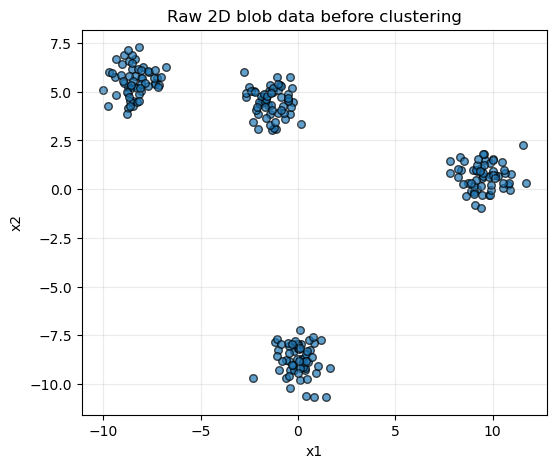

In [2]:
# Create a simple 2D dataset with 4 visible groups.
# We generate the data ourselves so we know the true number of groups.
# Later we will pretend we do not know this number and let K-Means discover it.
X_blob, y_blob_true = make_blobs(
    n_samples=240,
    centers=4,  # TODO: We want 4 natural blob groups. Enter that integer.
    cluster_std=0.75,
    random_state=7
)

blob_df = pd.DataFrame(X_blob, columns=["x1", "x2"])

print("Blob feature matrix shape:", X_blob.shape)
print("First five points:")
display(blob_df.head())

plt.figure(figsize=(6, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=30, edgecolor="k", alpha=0.7)
plt.title("Raw 2D blob data before clustering")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.25)
plt.show()


C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster labels shape: (240,)
Cluster centers shape: (4, 2)
K-Means objective value (inertia_): 257.76
Iterations to converge: 4


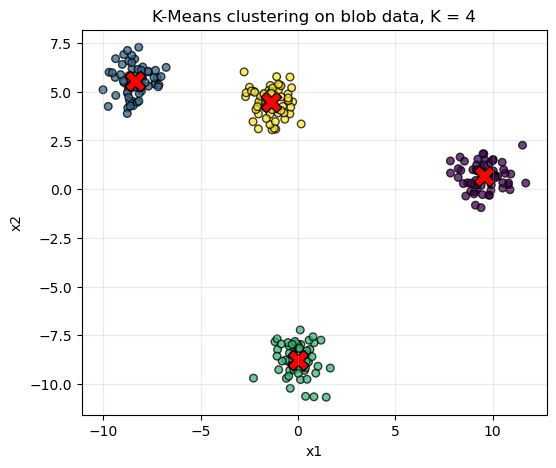

In [6]:
# Fit K-Means on the blob dataset.
# K-Means needs you to decide K upfront. After fitting, four things are stored on the model:
#   labels_          -- one cluster ID per data point
#   cluster_centers_ -- final center coordinates, one row per cluster
#   inertia_         -- the objective value (sum of squared distances from each point to its center)
#   n_iter_          -- how many update steps were needed before the algorithm converged
kmeans_blob = KMeans(
    n_clusters=4,  # TODO: How many clusters should K-Means look for? Use the same number of groups you generated above.
    init="random",
    n_init=10,
    random_state=3
)

kmeans_blob.fit(X_blob)  # TODO: What data should K-Means be fitted on? Pass the blob feature matrix here.

labels_blob    = kmeans_blob.labels_           # One cluster label per point.
centers_blob   = kmeans_blob.cluster_centers_  # Final center coordinates.
objective_blob = kmeans_blob.inertia_          # K-Means objective value.
iterations_blob = kmeans_blob.n_iter_          # Iterations to converge.

print("Cluster labels shape:", labels_blob.shape)
print("Cluster centers shape:", centers_blob.shape)
print("K-Means objective value (inertia_):", round(objective_blob, 2))
print("Iterations to converge:", iterations_blob)

plt.figure(figsize=(6, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_blob, s=30, cmap="viridis", edgecolor="k", alpha=0.75)
plt.scatter(centers_blob[:, 0], centers_blob[:, 1], s=220, c="red", marker="X", edgecolor="k")
plt.title("K-Means clustering on blob data, K = 4")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.25)
plt.show()


In [11]:
# Inspect a few individual points and their assigned cluster centers.
# After K-Means runs, every point has a label. That label is also the row index
# of that point's assigned center inside cluster_centers_.
# So if a point has label 2, its center is cluster_centers_[2].
sample_indices = [0, 15, 40, 100, 180]
chosen_points  = X_blob[sample_indices]      # Select five rows from the data.
chosen_labels  = labels_blob[sample_indices] # Get the cluster label of each selected point.
chosen_centers = centers_blob[chosen_labels]  # TODO: Use chosen_labels to look up each point's assigned center. Think: if a point has label 2, which row of centers_blob is its center?

assignment_df = pd.DataFrame({
    "point_index":    sample_indices,
    "x1":             chosen_points[:, 0].round(2),
    "x2":             chosen_points[:, 1].round(2),
    "assigned_cluster": chosen_labels,
    "center_x1":      chosen_centers[:, 0].round(2),
    "center_x2":      chosen_centers[:, 1].round(2)
})

display(assignment_df)
chosen_labels


,point_index,x1,x2,assigned_cluster,center_x1,center_x2
0,0,-8.73,5.24,1,-8.38,5.55
1,15,10.80,0.22,0,9.57,0.66
2,40,0.09,-8.74,2,0.00,-8.74
3,100,-8.48,5.54,1,-8.38,5.55
4,180,-1.93,4.78,3,-1.38,4.48


array([1, 0, 2, 1, 3])

---
## Section 2: Initialization Matters in K-Means

This section also uses the same blob dataset.

Purpose:
- The K-Means slides say that initialization matters.
- One random initialization can be lucky or unlucky.
- Farthest-first initialization spreads starting centers across the data cloud.

We compare one intentionally unlucky random start with farthest-first initialization.

In [12]:
# Farthest-first initialization: a smarter way to pick starting centers than pure random.
#
# Step 1. Find the data mean. Pick the point farthest from that mean as the first center.
# Step 2. For each remaining center, find the point that is farthest from
#         its nearest already-chosen center. That point becomes the next center.
#
# The result is a set of starting centers that are spread out across the whole data cloud
# before K-Means even starts its first update step.
# Read through this function and make sure you understand each step before running it.
def farthest_first_centers(X, k):
    X = np.asarray(X)

    data_mean          =X.mean(axis=0)                           # TODO: Compute .mean of all input points.
    distance_from_mean = np.linalg.norm(X - data_mean , axis=1)   # TODO : Write each point's distance from the mean.
    first_index        = int(np.argmax(distance_from_mean))       # TODO : Find the point farthest from the mean.

    center_indices = [first_index]

    for _ in range(1, k):
        selected_centers         = X[center_indices]
        distances_to_selected    = np.linalg.norm(X[:, None, :] - selected_centers[None, :, :], axis=2)
        nearest_selected_distance = distances_to_selected.min(axis=1)  # Closest selected center per point.
        next_index               = int(np.argmax(nearest_selected_distance))  # Point farthest from its nearest center.
        center_indices.append(next_index)

    initial_centers = X[center_indices]
    return initial_centers, center_indices


Unlucky random center row indices: [162, 2, 179, 172]
Farthest-first center row indices: [104, 125, 99, 230]


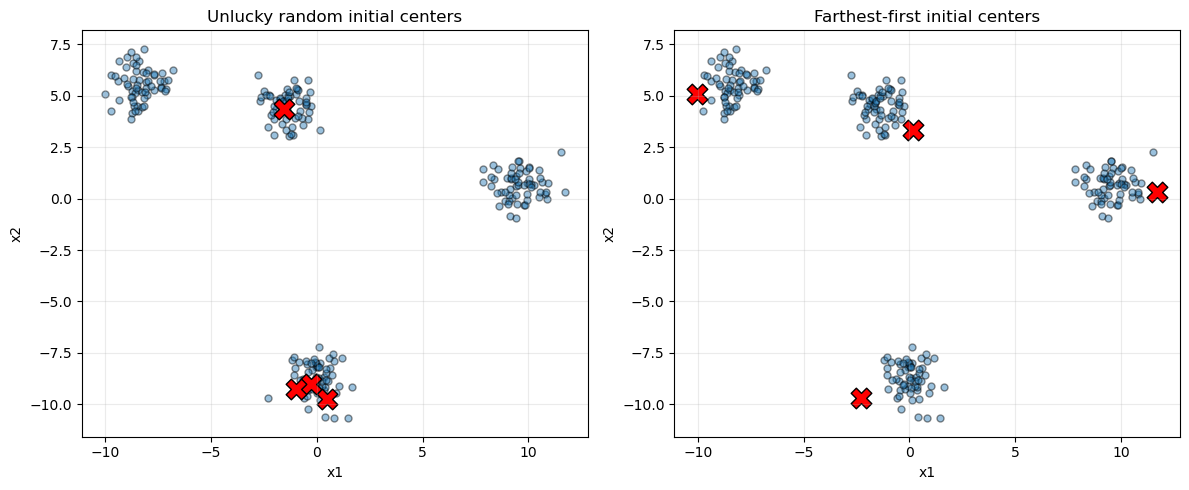

In [13]:
# Select initial centers using one unlucky random start and farthest-first.
# Both methods must pick exactly K starting centers.
rng = np.random.default_rng(53)
random_indices = rng.choice(len(X_blob), size= 4, replace=False)  # TODO: How many starting centers do we need? Set size to K.
random_centers = X_blob[random_indices] #TODO: Save the center indices

ff_centers, ff_indices = farthest_first_centers(X_blob, k=4)

print("Unlucky random center row indices:", random_indices.tolist())
print("Farthest-first center row indices:", ff_indices)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_blob[:, 0], X_blob[:, 1], s=25, edgecolor="k", alpha=0.45)
axes[0].scatter(random_centers[:, 0], random_centers[:, 1], s=220, c="red", marker="X", edgecolor="k")
axes[0].set_title("Unlucky random initial centers")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X_blob[:, 0], X_blob[:, 1], s=25, edgecolor="k", alpha=0.45)
axes[1].scatter(ff_centers[:, 0], ff_centers[:, 1], s=220, c="red", marker="X", edgecolor="k")
axes[1].set_title("Farthest-first initial centers")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


In [14]:
# Fit K-Means from both initializations and compare results.
# When you pass a NumPy array to init=, K-Means uses exactly those coordinates as starting centers
# and skips its own random initialization entirely.
# n_init=1 means only one run, so the result reflects exactly the initialization we supplied.
random_model = KMeans(
    n_clusters=4,
    init=random_centers,  # TODO: Pass the variable holding the unlucky random starting center coordinates.
    n_init=1,
    random_state=11
)
random_model.fit(X_blob)

ff_model = KMeans(
    n_clusters=4,
    init=ff_centers,  # TODO: Pass the variable holding the farthest-first starting center coordinates.
    n_init=1,
    random_state=11
)
ff_model.fit(X_blob)

init_compare_df = pd.DataFrame({
    "initialization":           ["unlucky_random", "farthest_first"],
    "iterations_to_converge":   [random_model.n_iter_,   ff_model.n_iter_],
    "objective_value_inertia_": [random_model.inertia_,  ff_model.inertia_]
}).round(2)

display(init_compare_df)


C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,initialization,iterations_to_converge,objective_value_inertia_
0,unlucky_random,5,10845.59
1,farthest_first,2,257.76


Observation:

In this run, the unlucky random initialization places many starting centers in the same natural group. Because the initial centers do not cover the full dataset well, K-Means converges to a poor local solution.

Farthest-first initialization picks centers that are far apart. Even though these initial centers are not exactly in the middle of each group, they cover the data cloud better. In this run, that gives fewer iterations and a much lower K-Means objective value.

---
## Section 3: Trying Different K Values

This section also uses the same blob dataset.

Purpose:
- In real clustering, we usually do not know K in advance.
- We try multiple K values and compare the outputs.
- We plot cluster results side by side, similar to the original lab notebook.
- We also use silhouette analysis, similar to the lecture slides.

Note: scikit-learn calls the K-Means objective value `inertia_`. In the slides, the same idea is the sum of squared distances to assigned cluster centers.

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows wi

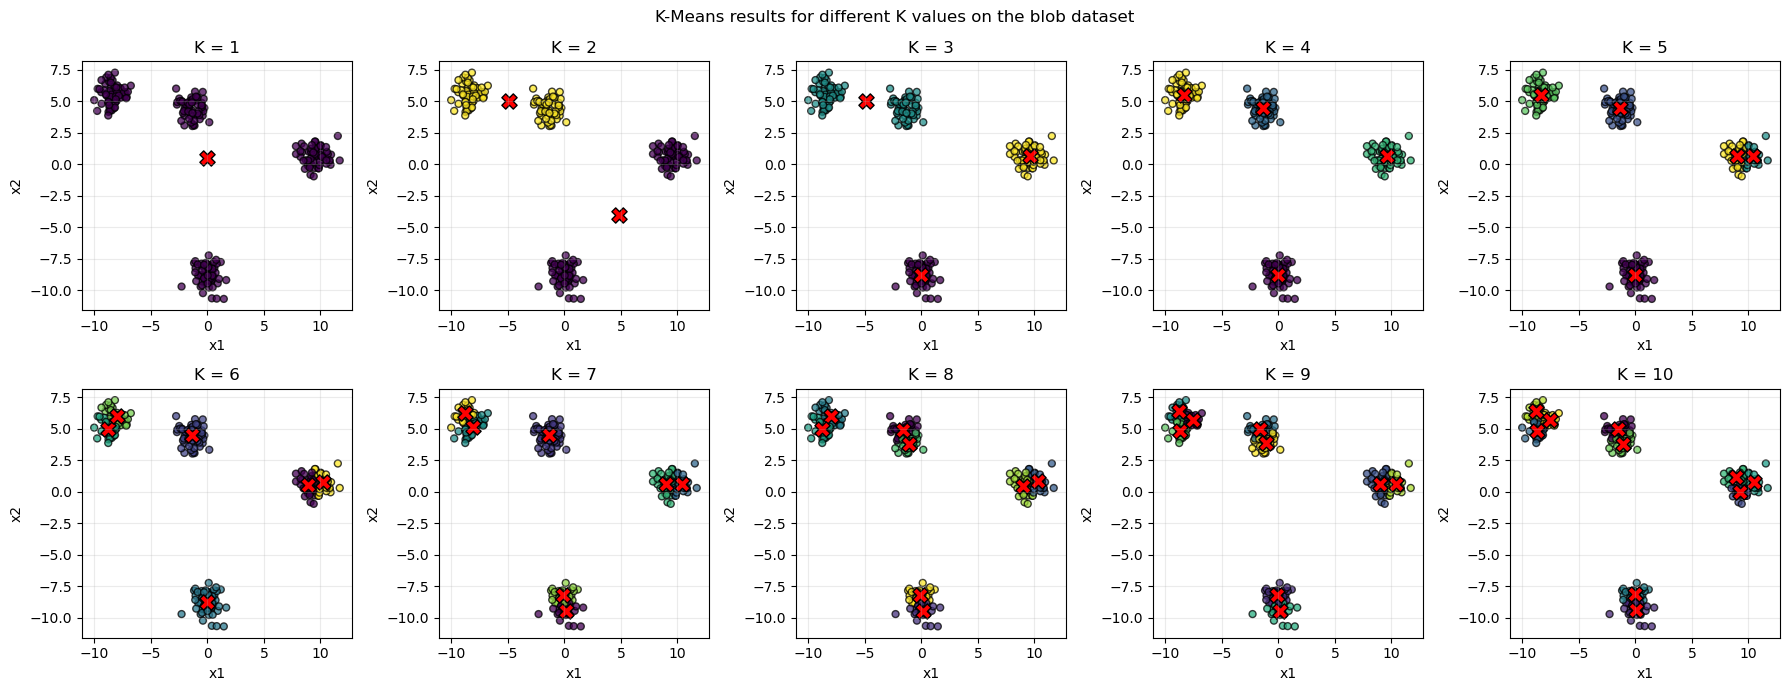

In [15]:
# Run K-Means for K = 1 to 10 and plot cluster results side by side.
# The loop has three jobs each iteration: create the model with the current K,
# fit it on the data, and save the objective value for the elbow plot below.
to_check_upto = 10
objective_values = []

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for k in range(1, to_check_upto + 1): # Loops over K = 1 to K = 10.
    model = KMeans(n_clusters=k, random_state=0, n_init=10)  # TODO: Use the current loop variable as n_clusters.
    model.fit(X_blob)  # TODO: Fit on the blob feature matrix.
    current_labels = model.labels_
    objective_values.append(model.inertia_)

    ax = axes[k - 1]
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=current_labels, s=25, cmap="viridis", edgecolor="k", alpha=0.75)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=120, c="red", marker="X", edgecolor="k")
    ax.set_title("K = " + str(k))
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.25)

plt.suptitle("K-Means results for different K values on the blob dataset")
plt.tight_layout()
plt.show()


,k,objective_value_inertia_
0,1,17695.45
1,2,7160.60
2,3,1761.41
3,4,257.76
4,5,230.64
5,6,204.63
6,7,182.84
7,8,157.33
8,9,140.98
9,10,126.61


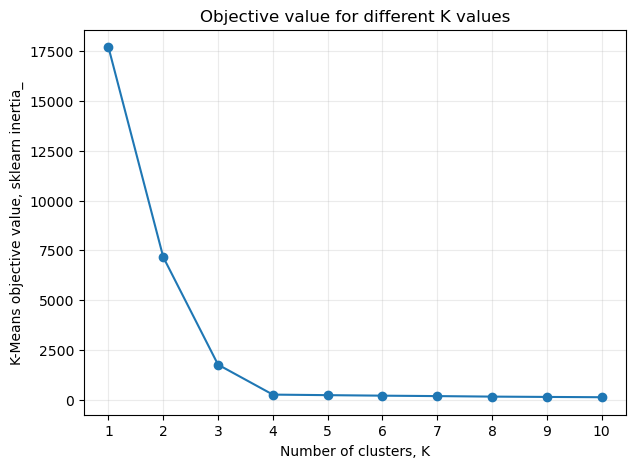

In [16]:
# Plot K against the K-Means objective value.
k_values = list(range(1, to_check_upto + 1))  # Creates the K values used on the x-axis.

objective_df = pd.DataFrame({  # Builds a table of K and objective values.
    "k": k_values,  # TODO: Stores K values.
    "objective_value_inertia_": np.round(objective_values, 2)  # Stores rounded objective values.
})

display(objective_df)  # Displays the objective value table.

plt.figure(figsize=(7, 5))  # Creates a figure for the curve.
plt.plot(k_values, objective_values, marker="o")  # Plots K against objective value.
plt.xticks(k_values)  # Shows every K value on the x-axis.
plt.xlabel("Number of clusters, K")  # Labels x-axis.
plt.ylabel("K-Means objective value, sklearn inertia_")  # Labels y-axis.
plt.title("Objective value for different K values")  # Adds plot title.
plt.grid(True, alpha=0.25)  # Adds light grid.
plt.show()  # Displays the plot.

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows wi

,k,silhouette_score
0,2,0.607
1,3,0.795
2,4,0.855
3,5,0.719
4,6,0.600
5,7,0.457
6,8,0.345
7,9,0.358
8,10,0.365


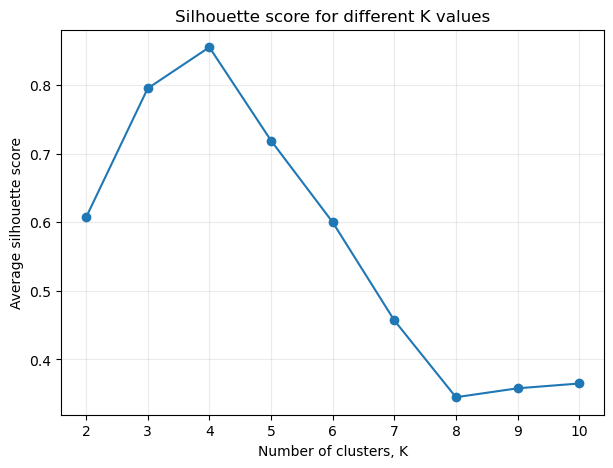

In [17]:
# Compute silhouette score for K = 2 to 10.
# Silhouette is not defined for K = 1 because there is no second cluster to compare a point against.
# A higher average silhouette score means points sit well inside their own cluster
# and are clearly separated from neighboring clusters.
silhouette_rows = []

for k in range(2, to_check_upto + 1):
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X_blob)
    current_labels = model.labels_
    score = silhouette_score(X_blob, current_labels)  # TODO: silhouette_score takes two arguments: the data matrix and the cluster labels. Fill them in.
    silhouette_rows.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_rows).round(3)
display(silhouette_df)

plt.figure(figsize=(7, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.xticks(silhouette_df["k"])
plt.xlabel("Number of clusters, K")
plt.ylabel("Average silhouette score")
plt.title("Silhouette score for different K values")
plt.grid(True, alpha=0.25)
plt.show()


In [20]:
# This function draws a detailed silhouette plot and cluster scatter side by side.
# Each horizontal band in the silhouette plot represents one cluster.
# Band width shows how high the silhouette scores for that cluster are.
# The red dashed vertical line marks the overall average silhouette score.
# Read through it once, then run the next cell to see the plots.
def plot_silhouette_for_k(X, k):
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X)
    labels  = model.labels_#TODO: Write parameter for model labels
    centers = model.cluster_centers_ #TODO: Write parameter for cluster centers

    average_score = silhouette_score(X, labels)
    sample_scores = silhouette_samples(X, labels)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax_silhouette = axes[0]
    ax_scatter    = axes[1]

    y_lower = 10
    for cluster_id in range(k):
        cluster_scores = sample_scores[labels == cluster_id]
        cluster_scores.sort() #TODO: Sorts scores so the silhouette shape is readable.
        cluster_size = cluster_scores.shape[0]
        y_upper = y_lower + cluster_size
        ax_silhouette.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_scores, alpha=0.7)
        ax_silhouette.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id))
        y_lower = y_upper + 10

    ax_silhouette.axvline(x=average_score, color="red", linestyle="--")
    ax_silhouette.set_title("Silhouette plot")
    ax_silhouette.set_xlabel("Silhouette coefficient values")
    ax_silhouette.set_ylabel("Cluster label")
    ax_silhouette.set_xlim([-0.1, 1])
    ax_silhouette.set_yticks([])

    ax_scatter.scatter(X[:, 0], X[:, 1], c=labels, s=25, cmap="viridis", edgecolor="k", alpha=0.75)
    ax_scatter.scatter(centers[:, 0], centers[:, 1], s=140, c="red", marker="X", edgecolor="k")
    ax_scatter.set_title("Clustered data")
    ax_scatter.set_xlabel("x1")
    ax_scatter.set_ylabel("x2")
    ax_scatter.grid(True, alpha=0.25)

    plt.suptitle("Silhouette analysis for K-Means with K = " + str(k))
    plt.tight_layout()
    plt.show()


C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


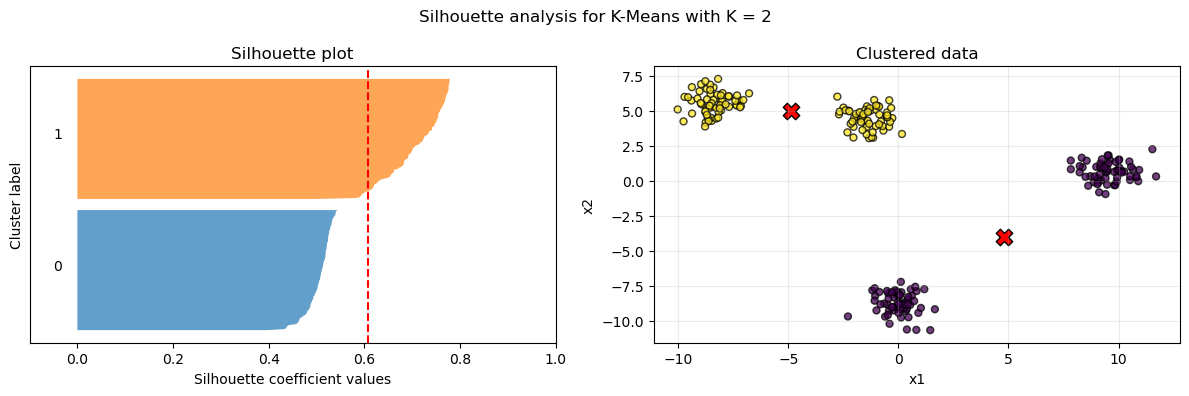

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


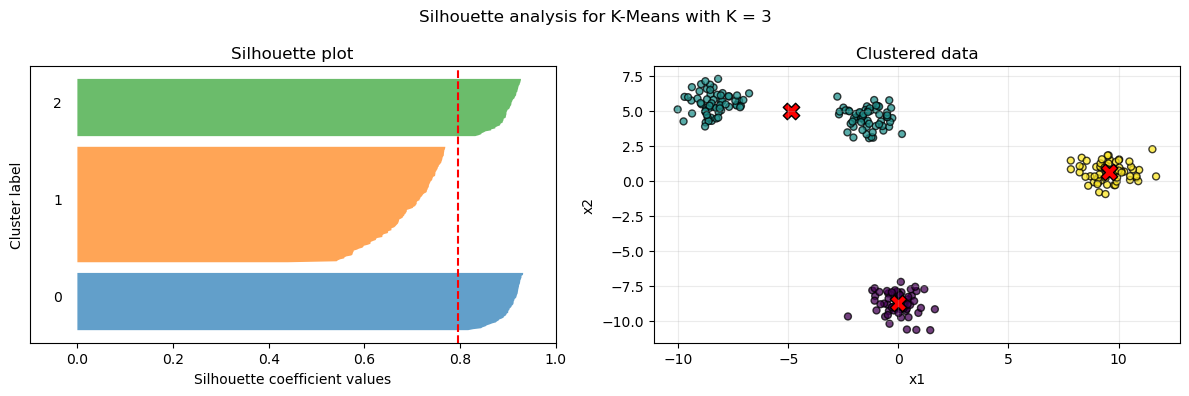

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


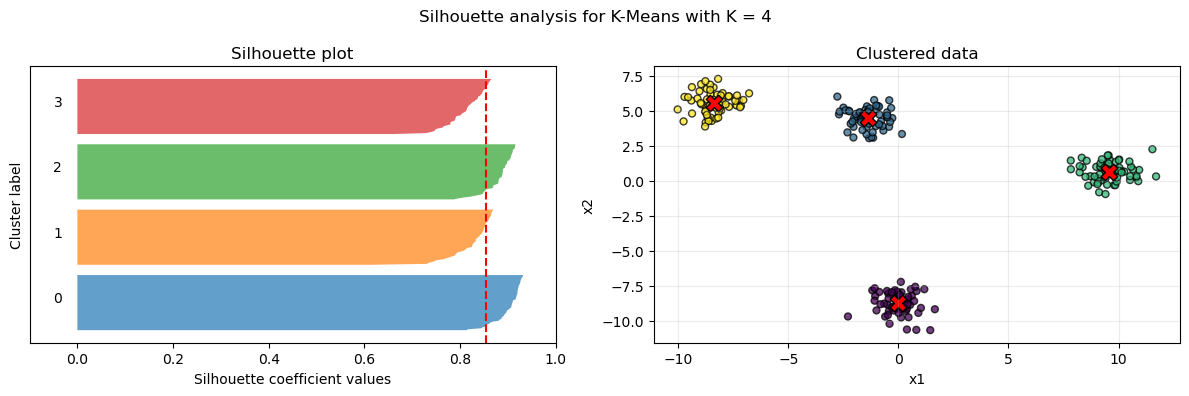

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


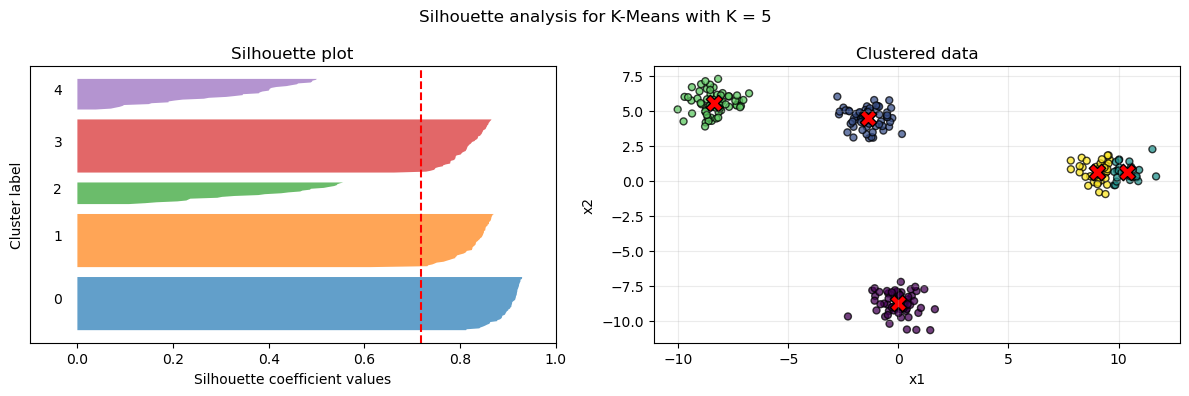

In [21]:
# Draw detailed silhouette plots for K = 2, 3, 4, and 5.
# Look at the band widths and how many points fall below the average score line.
# A good K has wide bands for all clusters and few points below the average line.
for k in [2,3,4,5]:  # TODO: Fill in the list of K values you want to inspect: 2, 3, 4, and 5.
    plot_silhouette_for_k(X_blob, k)

---
## Section 4: Agglomerative Clustering and Linkage Methods

This section has two parts.

Part A uses a small hand-made dataset so the dendrogram is readable. This is where students can see how linkage methods change the merge structure.

Part B uses the blob dataset again to show the final flat clustering result when we ask for K = 4 clusters.

Linkage meaning:
- Single linkage: distance between clusters is based on the closest pair of points.
- Complete linkage: distance between clusters is based on the farthest pair of points.
- Average linkage: distance between clusters is based on the average pairwise distance.

,x1,x2,point_label
0,0.0,0.0,0
1,0.4,0.1,1
2,0.9,0.2,2
3,1.4,0.1,3
4,3.8,3.5,4
5,4.2,3.7,5
6,4.5,3.2,6
7,7.2,0.2,7
8,7.6,0.0,8
9,8.1,0.3,9


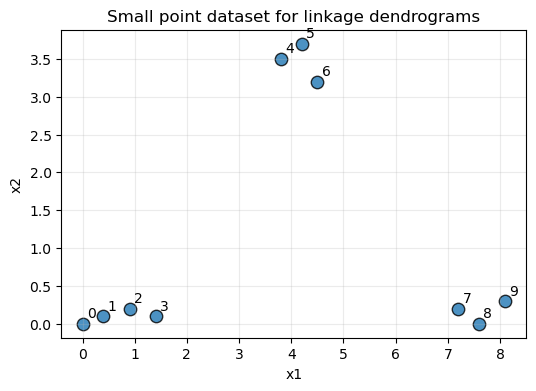

In [22]:
# Create a small 2D dataset for dendrograms.
# The dataset is small because dendrograms become hard to read with too many points.
small_points = np.array([  # Manually creates a small set of 2D points.
    [0.0, 0.0],  # Point 0.
    [0.4, 0.1],  # Point 1.
    [0.9, 0.2],  # Point 2.
    [1.4, 0.1],  # Point 3.
    [3.8, 3.5],  # Point 4.
    [4.2, 3.7],  # Point 5.
    [4.5, 3.2],  # Point 6.
    [7.2, 0.2],  # Point 7.
    [7.6, 0.0],  # Point 8.
    [8.1, 0.3]  # Point 9.
])

small_point_labels = [str(i) for i in range(len(small_points))]  # Creates text labels for points.

small_df = pd.DataFrame(small_points, columns=["x1", "x2"])  # Converts points to a DataFrame.
small_df["point_label"] = small_point_labels  # Adds point labels to the table.
display(small_df)  # Displays the small dataset.

plt.figure(figsize=(6, 4))  # Creates a figure for the small dataset.
plt.scatter(small_points[:, 0], small_points[:, 1], s=80, edgecolor="k", alpha=0.8)  # Plots the points.

for i, point in enumerate(small_points):  # Loops through points so labels can be drawn.
    plt.text(point[0] + 0.08, point[1] + 0.08, str(i), fontsize=10)  # Writes point number near each point.

plt.title("Small point dataset for linkage dendrograms")  # Adds title.
plt.xlabel("x1")  # Labels x-axis.
plt.ylabel("x2")  # Labels y-axis.
plt.grid(True, alpha=0.25)  # Adds a light grid.
plt.show()  # Displays the plot.

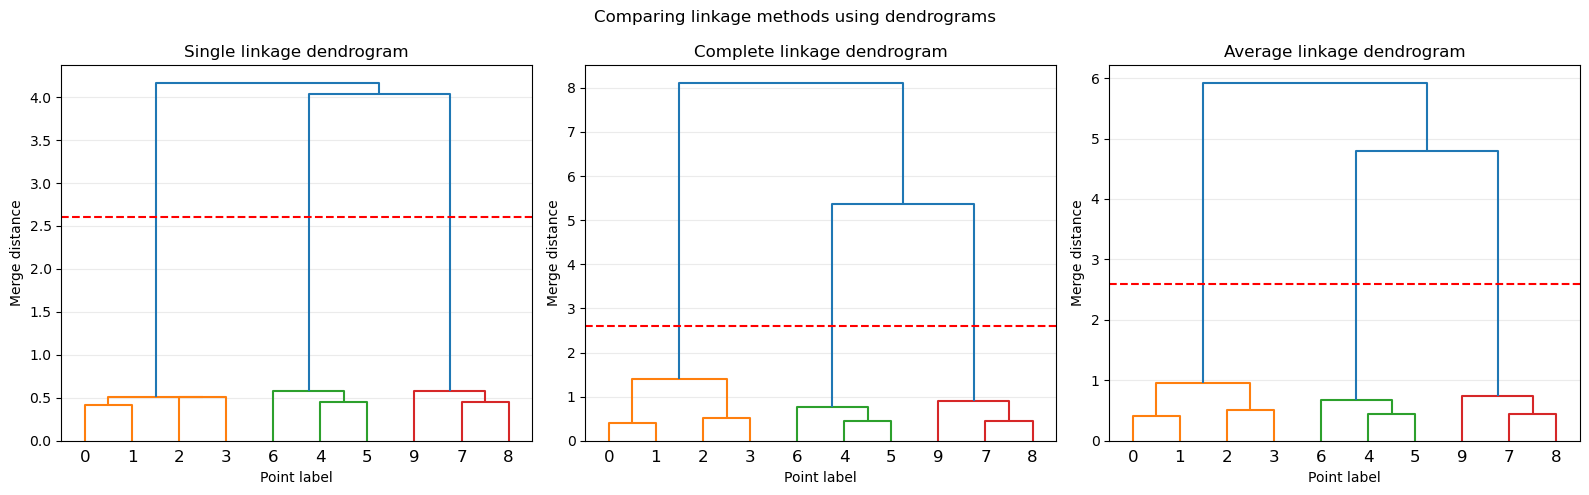

In [23]:
# Draw dendrograms for single, complete, and average linkage.
# Each dendrogram shows the same ten points merged in a different order.
# The merge order changes because each linkage rule measures cluster-to-cluster
# distance differently:
#   single   -- distance between the two closest points across clusters
#   complete -- distance between the two farthest points across clusters
#   average  -- average of all pairwise distances across clusters
# The red dashed line is a cut height. Every merge below the line produces one cluster.
linkage_methods = ["single", "complete", "average"]  # TODO: Fill in the three linkage method strings.
cut_height = 2.6

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, method in zip(axes, linkage_methods):
    Z_small = linkage(small_points, method=method)
    dendrogram(Z_small, labels=small_point_labels, ax=ax, color_threshold=cut_height)
    ax.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(method.capitalize() + " linkage dendrogram")
    ax.set_xlabel("Point label")
    ax.set_ylabel("Merge distance")
    ax.grid(True, axis="y", alpha=0.25)

plt.suptitle("Comparing linkage methods using dendrograms")
plt.tight_layout()
plt.show()


In [24]:
# Cut each dendrogram at cut_height and count the resulting clusters.
# fcluster returns one integer label per point. The number of unique labels
# tells you how many clusters the cut produced.
# Notice that the same cut height gives different cluster counts for different linkage methods.
linkage_cut_rows = []

for method in linkage_methods:
    Z_small    = linkage(small_points, method=method)
    flat_labels = fcluster(Z_small, t=cut_height, criterion="distance")
    number_of_clusters = len(np.unique(flat_labels))
    linkage_cut_rows.append({
        "linkage_method":      method,
        "cut_height":          cut_height,
        "clusters_after_cut":  number_of_clusters,
        "point_cluster_labels": flat_labels.tolist()
    })

linkage_cut_df = pd.DataFrame(linkage_cut_rows)
display(linkage_cut_df)


,linkage_method,cut_height,clusters_after_cut,point_cluster_labels
0,single,2.6,3,"[1, 1, 1, 1, 2, 2, 2, 3, 3, 3]"
1,complete,2.6,3,"[1, 1, 1, 1, 2, 2, 2, 3, 3, 3]"
2,average,2.6,3,"[1, 1, 1, 1, 2, 2, 2, 3, 3, 3]"


Observation:

The dendrograms make the linkage differences visible. The same points can merge at different heights depending on how cluster-to-cluster distance is defined. A horizontal cut line converts the hierarchy into flat clusters.

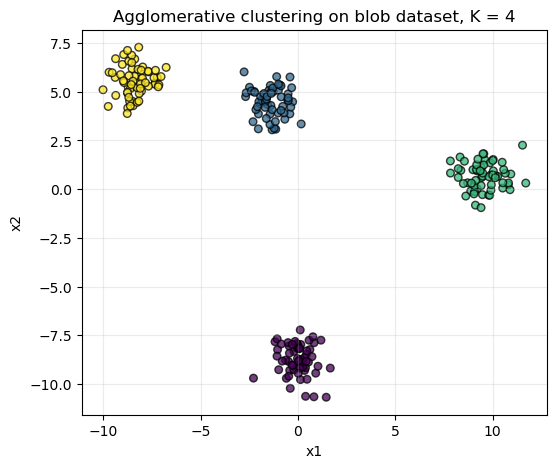

In [25]:
# Apply agglomerative clustering to the full blob dataset.
# Unlike K-Means, AgglomerativeClustering does not produce cluster_centers_.
# It builds the full hierarchy internally and cuts it to give n_clusters flat groups.
agg_blob = AgglomerativeClustering(
    n_clusters=4,  # TODO: How many final clusters do you want? Match the blob dataset.
    linkage="average"     # TODO: Which linkage method should be used? Use "average".
)

agg_blob.fit(X_blob)
agg_blob_labels = agg_blob.labels_

plt.figure(figsize=(6, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=agg_blob_labels, s=30, cmap="viridis", edgecolor="k", alpha=0.75)
plt.title("Agglomerative clustering on blob dataset, K = 4")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.25)
plt.show()


---
## Section 5: Wine Dataset and Feature Correlation Clustering

This section uses the built-in Wine dataset.

Important difference:
- Earlier sections clustered rows, meaning data points.
- This section clusters columns, meaning features.

Purpose:
- The spectral clustering slides discuss feature correlation graphs.
- A correlation matrix can be treated as a feature similarity graph.
- If two features are highly correlated, they are similar.
- We convert similarity into distance using `distance = 1 - absolute correlation`.

Wine feature matrix shape: (178, 13)
Correlation matrix shape: (13, 13)


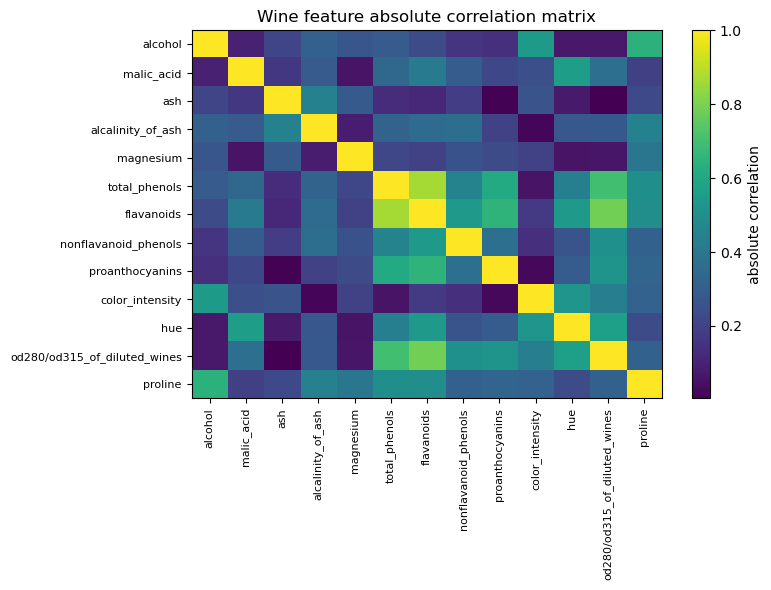

In [26]:
# Load the built-in Wine dataset and compute a feature distance matrix.
# In this section we cluster features, not samples.
# Two features that are highly correlated are considered similar (small distance).
# We define: distance = 1 - |correlation|
# So correlation of 1.0 gives distance 0.0 (identical), and correlation of 0.0 gives distance 1.0 (unrelated).
wine  = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

corr_abs = X_wine.corr().abs()  # Absolute pairwise correlation between every pair of features.

corr_distance_array = (1- corr_abs).to_numpy(copy=True)  # TODO: Apply the formula distance = 1 - |correlation|. What number goes here?
np.fill_diagonal(corr_distance_array, 0)  # TODO: A feature's distance from itself should be exactly zero. What value goes here?

corr_distance = pd.DataFrame(
    corr_distance_array,
    index=corr_abs.index,
    columns=corr_abs.columns
)

print("Wine feature matrix shape:", X_wine.shape)
print("Correlation matrix shape:", corr_abs.shape)

plt.figure(figsize=(8, 6))
plt.imshow(corr_abs, aspect="auto")
plt.colorbar(label="absolute correlation")
plt.xticks(range(len(X_wine.columns)), X_wine.columns, rotation=90, fontsize=8)
plt.yticks(range(len(X_wine.columns)), X_wine.columns, fontsize=8)
plt.title("Wine feature absolute correlation matrix")
plt.tight_layout()
plt.show()


,feature,feature_group
1,malic_acid,1
10,hue,1
5,total_phenols,2
6,flavanoids,2
8,proanthocyanins,2
11,od280/od315_of_diluted_wines,2
7,nonflavanoid_phenols,3
2,ash,4
3,alcalinity_of_ash,5
0,alcohol,6


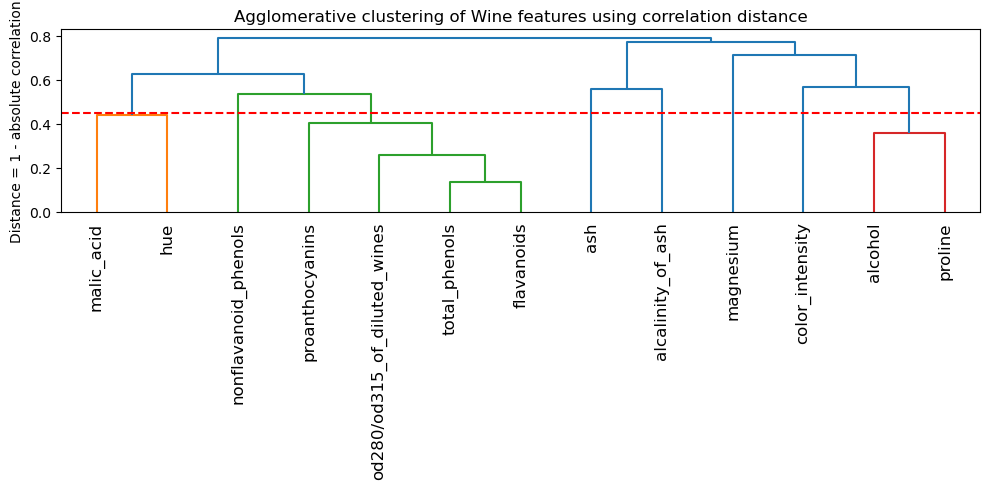

In [27]:
# Build a dendrogram from the Wine feature distance matrix and group features.
# squareform converts the full square distance matrix to the condensed format linkage expects.
# After you run this cell, look at the dendrogram and consider:
# does the cut at feature_cut_height = 0.45 produce sensible feature groups?
condensed_corr_distance = squareform(corr_distance_array, checks=False)
Z_features = linkage(condensed_corr_distance, method="average")
feature_cut_height = 0.45
feature_groups = fcluster(Z_features, t=feature_cut_height, criterion="distance")  # TODO: Cut the feature dendrogram at feature_cut_height.

feature_group_df = pd.DataFrame({
    "feature":       X_wine.columns,
    "feature_group": feature_groups
}).sort_values("feature_group")

display(feature_group_df)

plt.figure(figsize=(10, 5))
dendrogram(Z_features, labels=X_wine.columns.tolist(), leaf_rotation=90)
plt.axhline(y=feature_cut_height, color="red", linestyle="--", linewidth=1.5)
plt.title("Agglomerative clustering of Wine features using correlation distance")
plt.ylabel("Distance = 1 - absolute correlation")
plt.tight_layout()
plt.show()


---
## Section 6: Spectral Clustering on a Non-Spherical Dataset

This section uses a two-moons dataset.

Purpose:
- K-Means works best when clusters are roughly round.
- The moons dataset has curved clusters.
- Spectral clustering uses a graph idea, so it can handle some non-spherical structures better.

This section is short because the main lab focus is K-Means and Agglomerative Clustering.

C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


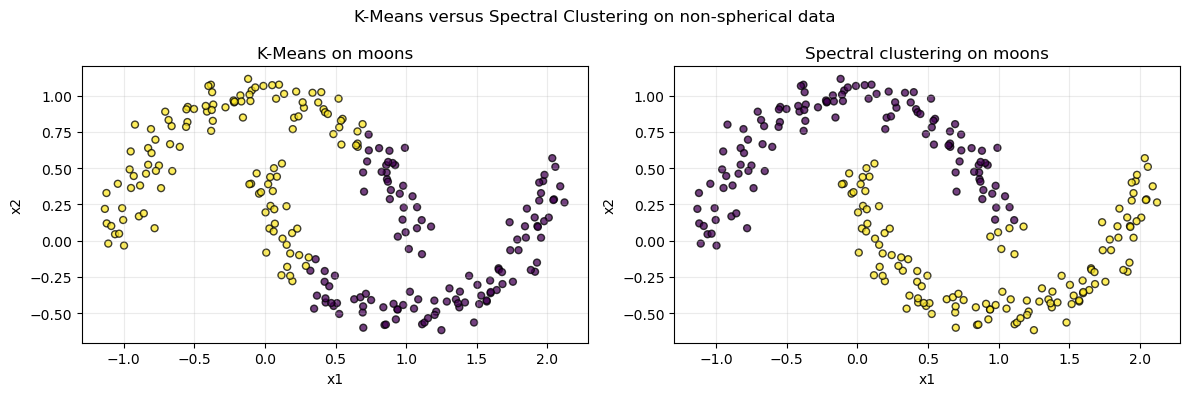

In [28]:
# Create a two-moons dataset and compare K-Means with Spectral Clustering.
# K-Means assumes clusters are round blobs. The moon shapes are curved, so K-Means
# will split them along a straight boundary instead of following the curve.
# Spectral Clustering builds a graph connecting nearby points and clusters the graph,
# which lets it follow curved boundaries.
X_moon, y_moon_true = make_moons(n_samples=240, noise=0.08, random_state=12)

kmeans_moon = KMeans(n_clusters=2, n_init=10, random_state=12)  # TODO: There are two moon shapes. How many clusters should K-Means look for?
kmeans_moon.fit(X_moon)
kmeans_moon_labels = kmeans_moon.labels_

spectral_moon = SpectralClustering(
    n_clusters=2, # TODO: Same question. How many clusters for Spectral Clustering?
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=12
)
spectral_moon.fit(X_moon)
spectral_moon_labels = spectral_moon.labels_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=kmeans_moon_labels, s=25, cmap="viridis", edgecolor="k", alpha=0.75)
axes[0].set_title("K-Means on moons")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=spectral_moon_labels, s=25, cmap="viridis", edgecolor="k", alpha=0.75)
axes[1].set_title("Spectral clustering on moons")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].grid(True, alpha=0.25)

plt.suptitle("K-Means versus Spectral Clustering on non-spherical data")
plt.tight_layout()
plt.show()


---
## Exit Questions

Answer these after completing the lab. Use the outputs that you generated.

**Q1. In Section 1, what do `labels_`, `cluster_centers_`, `inertia_`, and `n_iter_` tell you?**

Answer:labels_ : tells us which cluster each data point has been assigned to.
cluster_centers_ : gives the coordinates of the final cluster centroids found by K-Means.
inertia_ : represents the K-Means objective value, i.e., the sum of squared distances between points and their assigned cluster centers.Lower values generally indicate tighter clusters.
n_iter_ : shows how many iterations K-Means needed before it converged to a stable solution.

**Q2. In Section 2, which initialization gave the lower final objective value in this run, and why?**

Answer:The farthest first initialization yielded the smaller final objective function value. 
This is due to the fact that this method selects centers that are distributed throughout the data space, thereby resulting in good initial distribution of the clusters.
The random initialization was unfortunate enough to have initialized centers in proximity to each other.

**Q3. In Section 3, why does the K-Means objective value usually decrease as K increases?**

Answer:As the number of K increases, the number of centroids also increases. 
Therefore, the distance between data points and centroids is shortened. 
Inertia is the measure of these distances; thus, the objective function value usually decreases as K increases.

**Q4. In Section 3, which K looked strongest for the blob dataset, based on the plots and silhouette analysis?**

Answer:K = 4 appeared to be the strongest choice. 
The blob dataset was generated with four natural groups, and the clustering plots showed clear separation at K = 4. 
The silhouette analysis also indicated strong cluster quality around this value, with good cohesion within clusters and separation between clusters.

**Q5. In Section 4, why are dendrograms better than only scatter plots for teaching linkage methods?**

Answer:While dendrograms represent the whole hierarchy of the combination of all clusters, a scatter plot represents just the final results of the clustering procedure. 
It is important to note that a dendrogram enables us to know how various linkage algorithms work by showing how different clusters are joined during the clustering process.

**Q6. In Section 4, what does the horizontal cut line on a dendrogram represent?**

Answer:The line of horizontal cutting denotes a certain distance threshold value.
Any clusters that form below the line constitute a single cluster. 
The cutting of the dendrogram at a certain level converts the hierarchical organization of data to flat clusters.

**Q7. In Section 5, are we clustering Wine samples or Wine features?**

Answer: In Section 5, we are clustering Wine features.The goal is to group features that behave similarly based on their correlations with one another.

**Q8. In Section 5, why do we use `1 - absolute correlation` as a distance?**

Answer: In absolute correlation, the degree to which two attributes are related does not matter. 
In other words, whether the two variables have a positive or negative relationship is irrelevant to absolute correlation.
Using distance = 1 – |correlation|, high correlations will have a low distance, meaning they are more similar.

**Q9. In Section 6, why does Spectral Clustering work better than K-Means on the moons dataset?**

Answer:In the moons dataset, the shape of the clusters is not spherical. 
K-Means is based on the assumption that clusters are roughly circular; thus, it performs poorly on data having clusters in curved form. 
Spectral Clustering works by creating a graph of neighboring points. 
The clustering process then relies on connectivity of the points to form clusters.

---
## Functions, Arguments, and Attributes Used in This Lab

### NumPy

**`np.asarray(a)`**
```python
np.asarray(X)
```
Converts input into a NumPy array. Official page: https://numpy.org/doc/stable/reference/generated/numpy.asarray.html

**`array.mean(axis=0)`**
```python
X.mean(axis=0)
```
Computes column means when `axis=0`. Official page: https://numpy.org/doc/stable/reference/generated/numpy.mean.html

**`np.linalg.norm(x, axis=1)`**
```python
np.linalg.norm(X - data_mean, axis=1)
```
Computes Euclidean distances for rows when `axis=1`. Official page: https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html

**`np.argmax(a)`**
```python
np.argmax(distance_values)
```
Returns the index of the largest value. Official page: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html

**`np.fill_diagonal(a, value)`**
```python
np.fill_diagonal(corr_distance_array, 0)
```
Fills the diagonal of an array. Official page: https://numpy.org/doc/stable/reference/generated/numpy.fill_diagonal.html

### pandas

**`pd.DataFrame(data, columns=...)`**
```python
pd.DataFrame(X_blob, columns=["x1", "x2"])
```
Creates a table with named columns. Official page: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

**`DataFrame.corr()`**
```python
X_wine.corr()
```
Computes pairwise feature correlations. Official page: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

### scikit-learn datasets

**`make_blobs()`**
```python
make_blobs(n_samples=240, centers=4, cluster_std=0.75, random_state=7)
```
Creates synthetic blob-like clusters. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html

**`load_wine()`**
```python
load_wine()
```
Loads the built-in Wine dataset. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html

**`make_moons()`**
```python
make_moons(n_samples=240, noise=0.08, random_state=12)
```
Creates two curved moon-shaped groups. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html

### scikit-learn clustering

**`KMeans()`**
```python
KMeans(n_clusters=4, init="random", n_init=10, random_state=3)
```
Creates a K-Means model. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Common K-Means arguments:
- `n_clusters`: number of clusters K.
- `init`: how starting centers are chosen.
- `n_init`: number of initializations tried.
- `random_state`: makes random behavior reproducible.

Common K-Means attributes:
- `labels_`: final cluster label for each point.
- `cluster_centers_`: final center coordinates.
- `inertia_`: scikit-learn name for the K-Means objective value, the sum of squared distances to assigned centers.
- `n_iter_`: number of iterations used before convergence.

**`silhouette_score(X, labels)`**
```python
silhouette_score(X_blob, labels)
```
Computes the average silhouette score. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

**`silhouette_samples(X, labels)`**
```python
silhouette_samples(X_blob, labels)
```
Computes silhouette score for each point. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html

**`AgglomerativeClustering()`**
```python
AgglomerativeClustering(n_clusters=4, linkage="average")
```
Creates a bottom-up hierarchical clustering model. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

**`SpectralClustering()`**
```python
SpectralClustering(n_clusters=2, affinity="nearest_neighbors", n_neighbors=10)
```
Creates a graph-based clustering model. Official page: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

### SciPy hierarchy functions

**`linkage(X, method=...)`**
```python
linkage(small_points, method="average")
```
Builds the hierarchical merge structure. Official page: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

**`dendrogram(Z, labels=...)`**
```python
dendrogram(Z_small, labels=small_point_labels)
```
Draws a dendrogram from a linkage matrix. Official page: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

**`fcluster(Z, t=..., criterion="distance")`**
```python
fcluster(Z_small, t=cut_height, criterion="distance")
```
Cuts a hierarchy into flat clusters. Official page: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.fcluster.html

**`squareform()`**
```python
squareform(corr_distance_array, checks=False)
```
Converts a square distance matrix into condensed format. Official page: https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html